# 06_causal_chain_visualization

This notebook visualizes causal chains extracted from ASRS narratives.
We convert temporal markers (e.g., "before", "during", "then", "finally") into
directed graphs that illustrate how events unfolded in each incident.

These visualizations help identify patterns in human factors, operational hazards,
and sequence‑driven risk escalation.

In [1]:
import pandas as pd
import numpy as np
import re
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# load data
df = pd.read_csv("../data/processed/asrs_extracted_offline_3yrs.csv")
print("Loaded:", df.shape)
df['causal_chain'].head()

Loaded: (16535, 131)


C:\Users\jenny\AppData\Local\Temp\ipykernel_15704\2468380901.py:2: DtypeWarning: Columns (7,8,15,19,20,38,39,40,41,42,43,44,45,46,47,48,49,50,59,63,78,79,81,82,83,86,89,99,100,110,111,123) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/asrs_extracted_offline_3yrs.csv")


0    ['Contains temporal marker: during', 'Contains...
1                  ['Contains temporal marker: after']
2    ['Contains temporal marker: before', 'Contains...
3                 ['Contains temporal marker: before']
4                                                  NaN
Name: causal_chain, dtype: object

In [3]:
TEMPORAL_MARKERS = [
    "before", "during", "after", "then", "subsequently", "eventually", "finally"
]

def extract_event_segments(text):
    if pd.isna(text):
        return []

    lower = text.lower()

    # Split on temporal markers while keeping them
    pattern = r"(" + "|".join(TEMPORAL_MARKERS) + r")"
    parts = re.split(pattern, lower)

    # Reconstruct segments: [marker + text]
    segments = []
    for i in range(1, len(parts), 2):
        marker = parts[i]
        description = parts[i+1].strip()
        segments.append(f"{marker}: {description}")

    return segments

In [4]:
df["event_segments"] = df["Narrative"].apply(extract_event_segments)
df["event_segments"].head()

0    [then: the aircraft started climbing out of 5;...
1    [after: exposure. this was by far the worst en...
2    [before: . while i was departing the area vfr ...
3    [before: departing; no matter what line mainte...
4                                                   []
Name: event_segments, dtype: object

In [9]:
import textwrap

def wrap_label(text, width=40):
    if not isinstance(text, str):
        return text
    return "\n".join(textwrap.wrap(text, width=width))

In [13]:
def format_label(text, width=40, max_lines=5):
    if not isinstance(text, str):
        return text

    wrapped = textwrap.wrap(text, width=width)

    # truncate if too long
    if len(wrapped) > max_lines:
        wrapped = wrapped[:max_lines]
        wrapped.append("...")

    return "\n".join(wrapped)

In [14]:
def build_graph(segments):
    G = nx.DiGraph()

    formatted = [format_label(seg) for seg in segments]

    for i in range(len(formatted) - 1):
        G.add_edge(formatted[i], formatted[i+1])

    return G

In [15]:
def plot_causal_graph(G, title="Causal Chain"):
    plt.figure(figsize=(14, 8))
    pos = nx.spring_layout(G, seed=42)

    nx.draw(
        G, pos,
        with_labels=True,
        node_size=3500,
        node_color="#87CEFA",
        font_size=9,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=15
    )

    plt.title(title)
    plt.show()

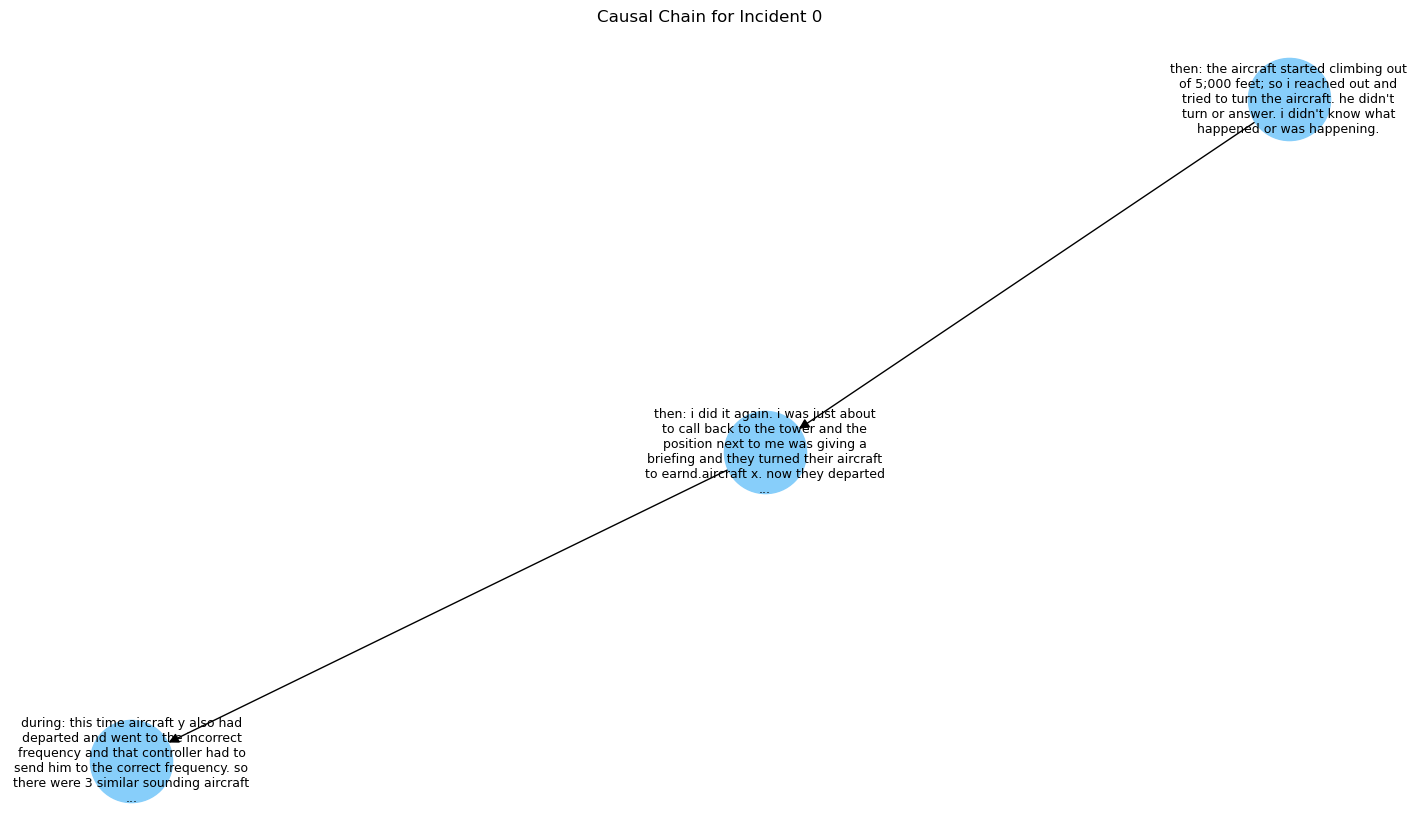

In [16]:
sample_idx = df[df["event_segments"].apply(len) > 2].index[0]
segments = df.loc[sample_idx, "event_segments"]

G = build_graph(segments)
plot_causal_graph(G, title=f"Causal Chain for Incident {sample_idx}")

In [17]:
output_file = "../data/processed/asrs_causal_segments_3yrs.csv"
df.to_csv(output_file, index=False)

print("Saved:", output_file)
print("Final shape:", df.shape)

Saved: ../data/processed/asrs_causal_segments_3yrs.csv
Final shape: (16535, 132)
